In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
deliveries=pd.read_csv("deliveries.csv")
matches=pd.read_csv("matches.csv")

In [4]:
deliveries.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [31]:
matches.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [5]:
matches.shape

(1095, 20)

In [6]:
deliveries.shape

(260920, 17)

In [7]:
matches['team1'].value_counts()

team1
Royal Challengers Bangalore    135
Chennai Super Kings            128
Mumbai Indians                 123
Kolkata Knight Riders          121
Rajasthan Royals               101
Kings XI Punjab                 92
Sunrisers Hyderabad             86
Delhi Daredevils                85
Delhi Capitals                  41
Deccan Chargers                 39
Punjab Kings                    31
Lucknow Super Giants            23
Pune Warriors                   23
Gujarat Titans                  21
Gujarat Lions                   16
Royal Challengers Bengaluru      9
Rising Pune Supergiant           7
Rising Pune Supergiants          7
Kochi Tuskers Kerala             7
Name: count, dtype: int64

In [8]:
matches['team2'].value_counts()

team2
Mumbai Indians                 138
Kolkata Knight Riders          130
Rajasthan Royals               120
Chennai Super Kings            110
Royal Challengers Bangalore    105
Kings XI Punjab                 98
Sunrisers Hyderabad             96
Delhi Daredevils                76
Delhi Capitals                  50
Deccan Chargers                 36
Punjab Kings                    25
Gujarat Titans                  24
Pune Warriors                   23
Lucknow Super Giants            21
Gujarat Lions                   14
Rising Pune Supergiant           9
Rising Pune Supergiants          7
Kochi Tuskers Kerala             7
Royal Challengers Bengaluru      6
Name: count, dtype: int64

In [9]:
deliveries['batting_team'].value_counts()

batting_team
Mumbai Indians                 31437
Kolkata Knight Riders          29514
Chennai Super Kings            28651
Royal Challengers Bangalore    28205
Rajasthan Royals               26242
Kings XI Punjab                22646
Sunrisers Hyderabad            21843
Delhi Daredevils               18786
Delhi Capitals                 10946
Deccan Chargers                 9034
Punjab Kings                    6833
Gujarat Titans                  5494
Pune Warriors                   5443
Lucknow Super Giants            5400
Gujarat Lions                   3566
Rising Pune Supergiant          1900
Royal Challengers Bengaluru     1818
Kochi Tuskers Kerala            1582
Rising Pune Supergiants         1580
Name: count, dtype: int64

### data Cleaning

In [11]:
# Rising Pune Supergiant
# Rising Pune Supergiants ....are same 
matches['team1'].replace({'Rising Pune Supergiants':'Rising Pune Supergiant'},inplace=True)
matches['team2'].replace({'Rising Pune Supergiants':'Rising Pune Supergiant'},inplace=True)
matches['toss_winner'].replace({'Rising Pune Supergiants':'Rising Pune Supergiant'},inplace=True)
matches['winner'].replace({'Rising Pune Supergiants':'Rising Pune Supergiant'},inplace=True)

In [37]:
# Royal Challengers Bangalore 
# Royal Challengers Bengaluru ....are same 
matches['team1'].replace({'Royal Challengers Bengaluru':'Royal Challengers Bangalore '},inplace=True)
matches['team2'].replace({'Royal Challengers Bengaluru':'Royal Challengers Bangalore '},inplace=True)
matches['toss_winner'].replace({'Royal Challengers Bengaluru':'Royal Challengers Bangalore '},inplace=True)
matches['winner'].replace({'Royal Challengers Bengaluru':'Royal Challengers Bangalore '},inplace=True)

In [38]:
matches['team2'].value_counts()

team2
Mumbai Indians                  138
Kolkata Knight Riders           130
Rajasthan Royals                120
Chennai Super Kings             110
Royal Challengers Bangalore     105
Kings XI Punjab                  98
Sunrisers Hyderabad              96
Delhi Daredevils                 76
Delhi Capitals                   50
Deccan Chargers                  36
Punjab Kings                     25
Gujarat Titans                   24
Pune Warriors                    23
Lucknow Super Giants             21
Rising Pune Supergiant           16
Gujarat Lions                    14
Kochi Tuskers Kerala              7
Royal Challengers Bangalore       6
Name: count, dtype: int64

In [40]:
# deliveries
deliveries['batting_team'].replace({'Rising Pune Supergiants':'Rising Pune Supergiant'},inplace=True)
deliveries['bowling_team'].replace({'Rising Pune Supergiants':'Rising Pune Supergiant'},inplace=True)

# deliveries
deliveries['batting_team'].replace({'Royal Challengers Bengaluru':'Royal Challengers Bangalore'},inplace=True)
deliveries['bowling_team'].replace({'Royal Challengers Bengaluru':'Royal Challengers Bangalore'},inplace=True)

In [14]:
deliveries['batting_team'].value_counts()

batting_team
Mumbai Indians                 31437
Royal Challengers Bangalore    30023
Kolkata Knight Riders          29514
Chennai Super Kings            28651
Rajasthan Royals               26242
Kings XI Punjab                22646
Sunrisers Hyderabad            21843
Delhi Daredevils               18786
Delhi Capitals                 10946
Deccan Chargers                 9034
Punjab Kings                    6833
Gujarat Titans                  5494
Pune Warriors                   5443
Lucknow Super Giants            5400
Gujarat Lions                   3566
Rising Pune Supergiant          3480
Kochi Tuskers Kerala            1582
Name: count, dtype: int64

In [15]:
matches['city'].value_counts()

city
Mumbai            173
Kolkata            93
Delhi              90
Chennai            85
Hyderabad          77
Bangalore          65
Chandigarh         61
Jaipur             57
Pune               51
Abu Dhabi          37
Ahmedabad          36
Bengaluru          29
Durban             15
Visakhapatnam      15
Lucknow            14
Dubai              13
Dharamsala         13
Centurion          12
Rajkot             10
Sharjah            10
Indore              9
Navi Mumbai         9
Johannesburg        8
Cuttack             7
Port Elizabeth      7
Ranchi              7
Cape Town           7
Raipur              6
Mohali              5
Kochi               5
Kanpur              4
Kimberley           3
East London         3
Guwahati            3
Nagpur              3
Bloemfontein        2
Name: count, dtype: int64

In [16]:
matches['city'].isnull().sum()

np.int64(51)

In [17]:
matches['method'].value_counts()

method
D/L    21
Name: count, dtype: int64

In [43]:
matches['city'].fillna('Unknown',inplace=True)
matches['method'].fillna('Non D/L',inplace=True)

### Success Rate of Team

In [19]:
matches

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,Non D/L,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,Non D/L,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,Non D/L,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,Non D/L,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,Non D/L,BF Bowden,K Hariharan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1090,1426307,2024,Hyderabad,2024-05-19,League,Abhishek Sharma,"Rajiv Gandhi International Stadium, Uppal, Hyd...",Punjab Kings,Sunrisers Hyderabad,Punjab Kings,bat,Sunrisers Hyderabad,wickets,4.0,215.0,20.0,N,Non D/L,Nitin Menon,VK Sharma
1091,1426309,2024,Ahmedabad,2024-05-21,Qualifier 1,MA Starc,"Narendra Modi Stadium, Ahmedabad",Sunrisers Hyderabad,Kolkata Knight Riders,Sunrisers Hyderabad,bat,Kolkata Knight Riders,wickets,8.0,160.0,20.0,N,Non D/L,AK Chaudhary,R Pandit
1092,1426310,2024,Ahmedabad,2024-05-22,Eliminator,R Ashwin,"Narendra Modi Stadium, Ahmedabad",Royal Challengers Bangalore,Rajasthan Royals,Rajasthan Royals,field,Rajasthan Royals,wickets,4.0,173.0,20.0,N,Non D/L,KN Ananthapadmanabhan,MV Saidharshan Kumar
1093,1426311,2024,Chennai,2024-05-24,Qualifier 2,Shahbaz Ahmed,"MA Chidambaram Stadium, Chepauk, Chennai",Sunrisers Hyderabad,Rajasthan Royals,Rajasthan Royals,field,Sunrisers Hyderabad,runs,36.0,176.0,20.0,N,Non D/L,Nitin Menon,VK Sharma


C:\Users\sumedh ingole\AppData\Local\Temp\ipykernel_1540\2441639760.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=success_ratio_desc.index, y=success_ratio_desc.values,palette="Set2",legend=False)


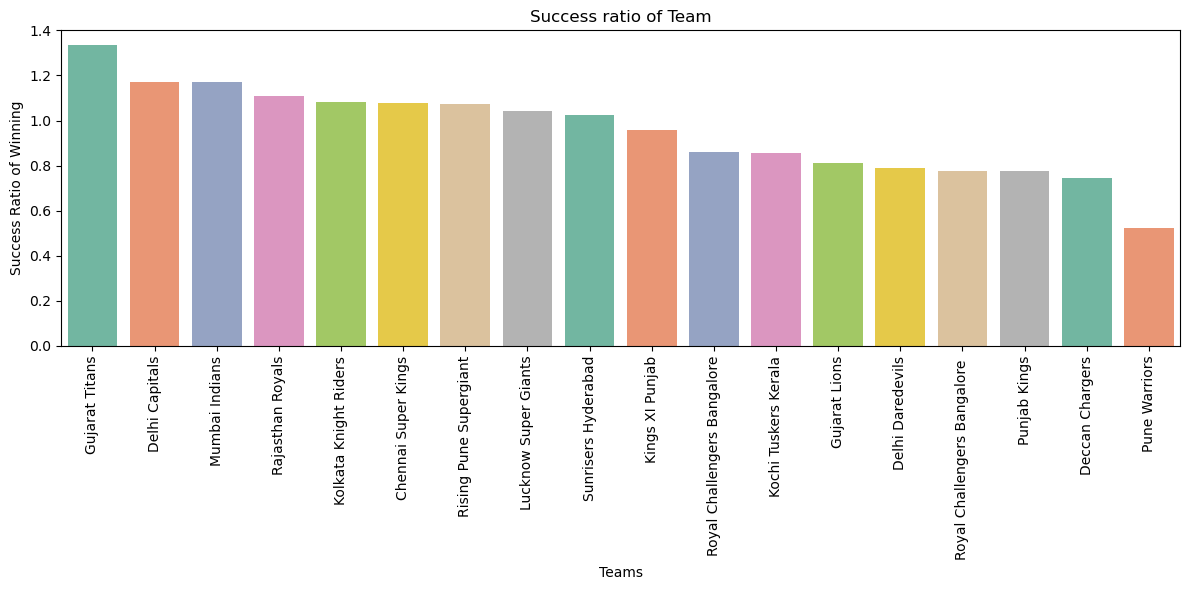

In [46]:
success_ratio=matches.groupby('winner').count()['id']/matches.groupby('team1').count()['id']
success_ratio_desc=success_ratio.sort_values(ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(x=success_ratio_desc.index, y=success_ratio_desc.values,palette="Set2",legend=False)
plt.title("Success ratio of Team")
plt.xlabel("Teams")
plt.ylabel("Success Ratio of Winning")  
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig("Success_Ratio_Of_Team.png")
plt.show()


# below is not an error it show future warning

### Most Titles Wins

C:\Users\sumedh ingole\AppData\Local\Temp\ipykernel_19936\423731573.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=winner_counts.index,y=winner_counts.values,palette="Set2")


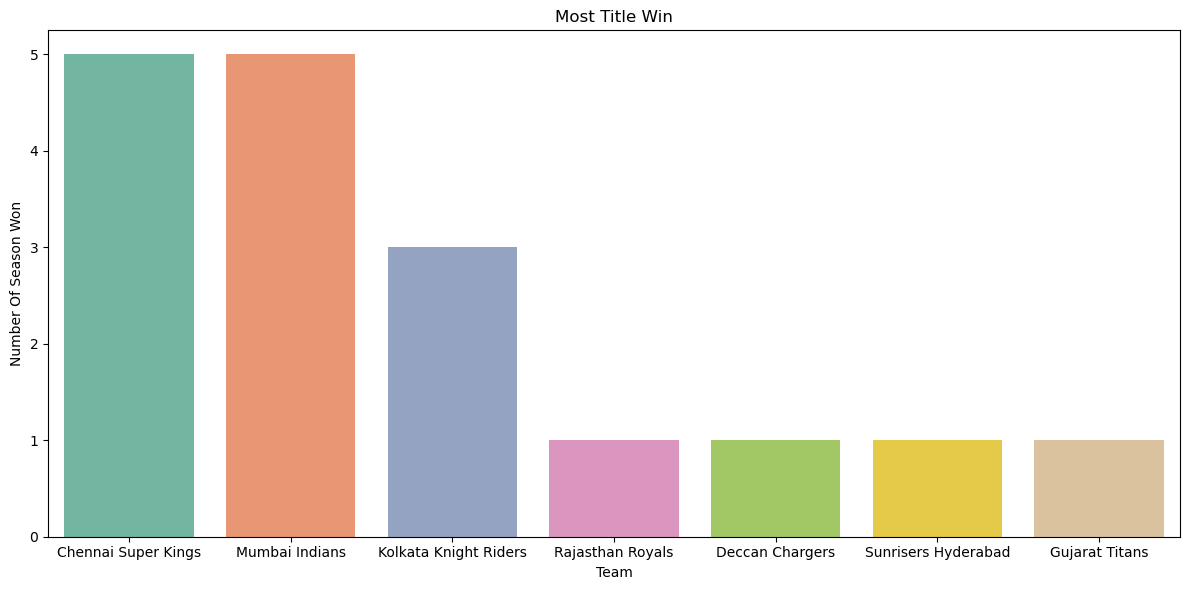

In [14]:
# matches.groupby('season')[['season','winner']].tail(1)
winner_counts=matches.groupby('season')[['season','winner']].tail(1)['winner'].value_counts()

plt.figure(figsize=(12,6))
sns.barplot(x=winner_counts.index,y=winner_counts.values,palette="Set2")
plt.title("Most Title Win")
plt.xlabel("Team")
plt.ylabel("Number Of Season Won")
plt.tight_layout()
plt.savefig("Team_of_Most_Title_Win.png")
plt.show()

### Top 10 Player With Most Runs (Orange Cap)

In [15]:
batting_tot= deliveries.groupby('batter')['batsman_runs'].sum().reset_index(name='Runs')
batting_tot.sort_values(by='Runs',ascending=False)[:10]

,batter,Runs
631,V Kohli,8014
512,S Dhawan,6769
477,RG Sharma,6630
147,DA Warner,6567
546,SK Raina,5536
374,MS Dhoni,5243
30,AB de Villiers,5181
124,CH Gayle,4997
501,RV Uthappa,4954
282,KD Karthik,4843


C:\Users\sumedh ingole\AppData\Local\Temp\ipykernel_19936\1985452248.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='batter',y='Runs',data= top_batsmen, palette="Set2")


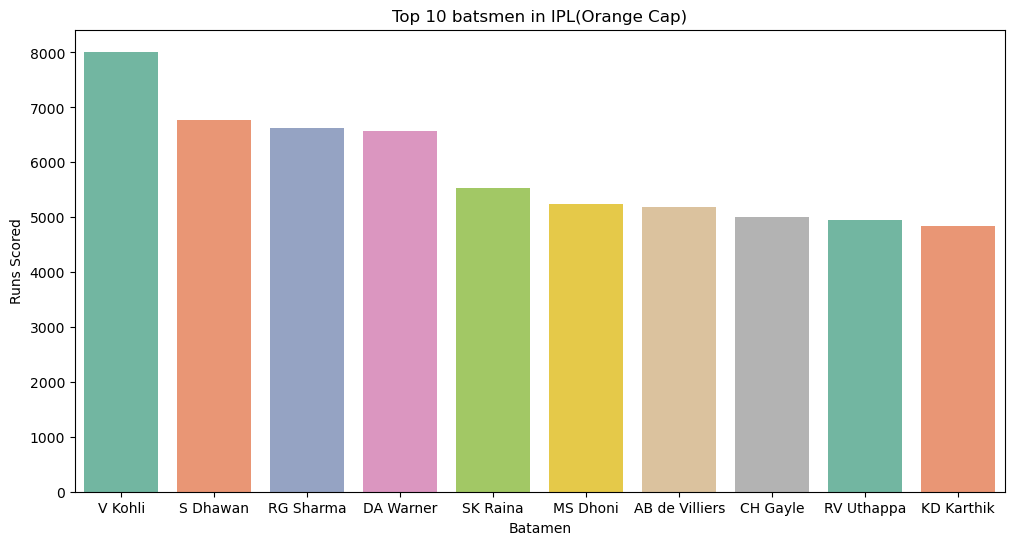

In [41]:
batting_tot= deliveries.groupby('batter')['batsman_runs'].sum().reset_index(name='Runs')
top_batsmen= batting_tot.sort_values(by='Runs',ascending=False)[:10]

plt.figure(figsize=(12,6))
sns.barplot(x='batter',y='Runs',data= top_batsmen, palette="Set2")
plt.title("Top 10 batsmen in IPL(Orange Cap)")
plt.xlabel("Batamen")
plt.ylabel("Runs Scored")
plt.savefig("Top_10_Batsmen.png")
plt.show()

#### Top 10 Best Performance in a Match

In [18]:
deliveries.head(1)

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN


In [19]:
# deliveries.groupby(['match_id','batter'])['batsman_runs'].sum()
batting_ings= deliveries.groupby(['match_id','batter'])['batsman_runs'].sum().reset_index(name='Innings Runs')
top_batsmen_scores= batting_ings.sort_values(by='Innings Runs',ascending=False)[:10]
print(top_batsmen_scores)

       match_id          batter  Innings Runs
5302     598027        CH Gayle           175
2        335982     BB McCullum           158
14108   1304112       Q de Kock           140
7528     829795  AB de Villiers           133
11583   1216510        KL Rahul           132
15383   1370352    Shubman Gill           129
8359     980987  AB de Villiers           129
4687     548372        CH Gayle           128
10149   1136602         RR Pant           128
2237     419137         M Vijay           127


In [20]:
batsman_ball_faced= deliveries.groupby(['match_id','batter'])['batsman_runs'].count().reset_index(name='Balls Faced')

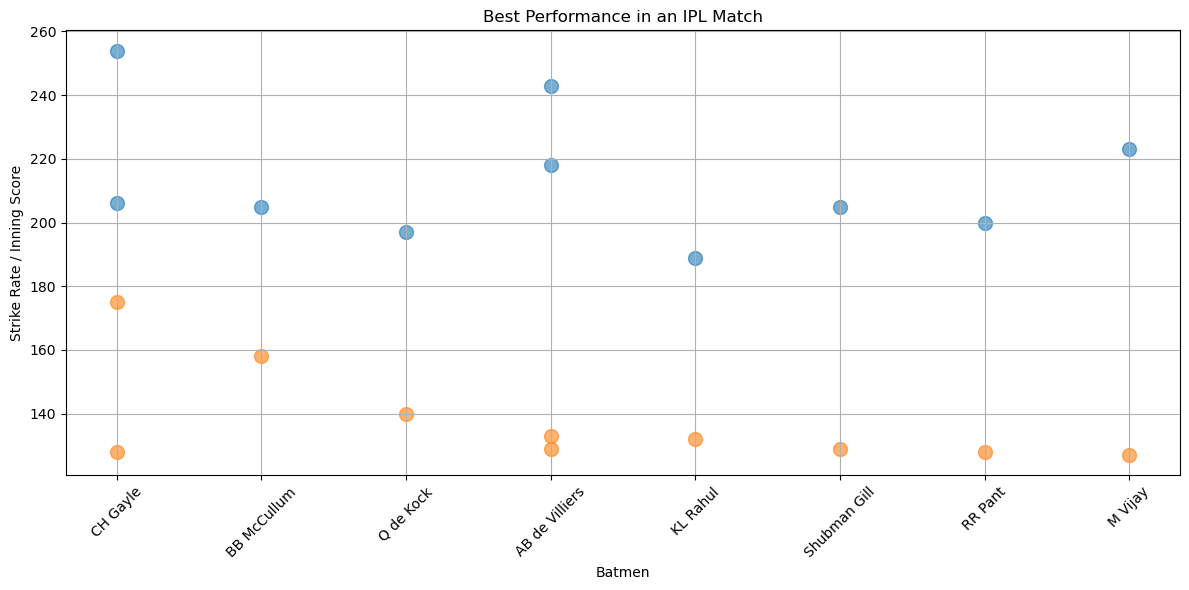

In [23]:
# np.round   for 2 digit
batsmen_performance= pd.merge(top_batsmen_scores,batsman_ball_faced, how='inner',on=['match_id','batter'])
batsmen_performance['Strike Rate for Match']=np.round(batsmen_performance['Innings Runs']*100/ batsmen_performance['Balls Faced'])
batsmen_performance


plt.figure(figsize=(12,6))
plt.scatter(batsmen_performance['batter'],batsmen_performance['Strike Rate for Match'],label='Strike Rate',s=100,alpha=0.6)
plt.scatter(batsmen_performance['batter'],batsmen_performance['Innings Runs'],label='Strike Rate',s=100,alpha=0.6)
plt.title('Best Performance in an IPL Match')
plt.xlabel('Batmen')
plt.ylabel('Strike Rate / Inning Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid()
plt.savefig("Best_Performance_an_IPL_Match.png")
plt.show()

### Top  10  Bowler till 2020

In [24]:
deliveries.head(1)

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN


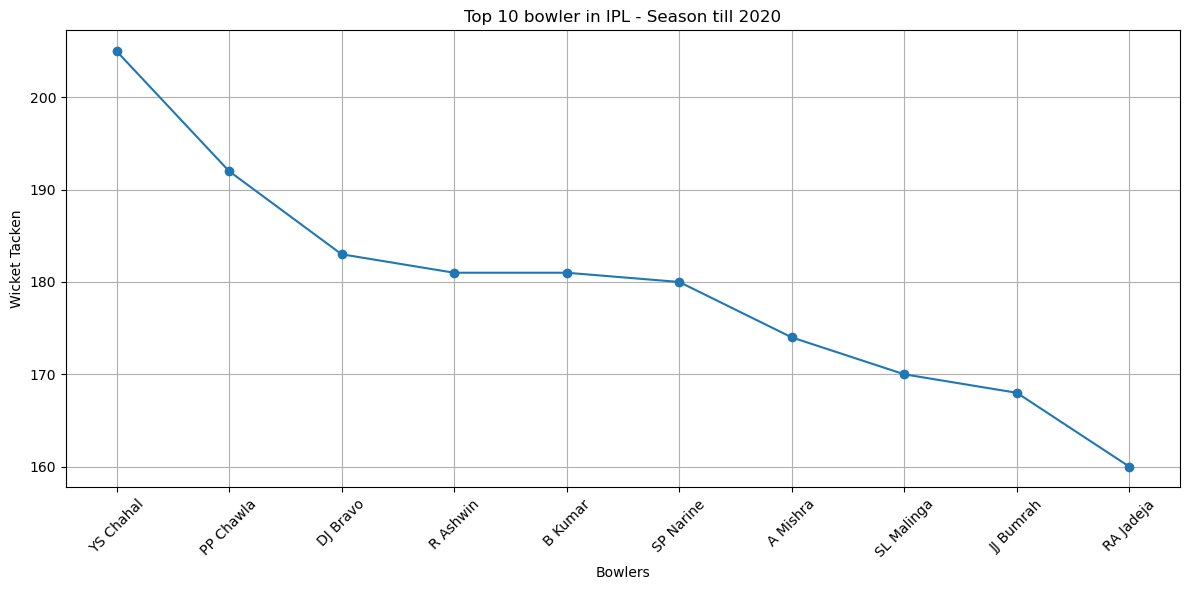

In [25]:
# deliveries['dismissal_kind'].value_counts()
bowling_wickets= deliveries[deliveries['dismissal_kind']!='run out']
top_bowlers= bowling_wickets.groupby('bowler')['dismissal_kind'].count().reset_index(
    name='Wicket').sort_values(by='Wicket',ascending=False)[:10]

plt.figure(figsize=(12,6))
plt.plot(top_bowlers['bowler'],top_bowlers['Wicket'],marker="o")
plt.title("Top 10 bowler in IPL(Purple Cap)")
plt.xlabel('Bowlers')
plt.ylabel('Wicket Tacken')
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid()
plt.savefig("Top_10_Bowler.png")
plt.show()

### Top 10 Bowling Performance till 2020


In [26]:
match_bowling_top= bowling_wickets.groupby(['match_id','bowler'])['dismissal_kind'].count().reset_index(
    name="Wickets").sort_values(by='Wickets',ascending=False)[:10]

In [27]:
match_bowler_runs= deliveries.groupby(['match_id','bowler'])['total_runs'].sum().reset_index(name="Runs Conceded")

In [28]:
match_bowler_performance= deliveries.groupby(['match_id','bowler'])['total_runs'].sum().reset_index(name='Runs Conceded')

In [29]:
pd.merge(match_bowler_runs,
         match_bowler_performance,how="inner",on=['match_id','bowler'])

,match_id,bowler,Runs Conceded_x,Runs Conceded_y
0,335982,AA Noffke,41,41
1,335982,AB Agarkar,25,25
2,335982,AB Dinda,9,9
3,335982,CL White,24,24
4,335982,I Sharma,13,13
...,...,...,...,...
12973,1426312,PJ Cummins,18,18
12974,1426312,SP Narine,20,20
12975,1426312,Shahbaz Ahmed,28,28
12976,1426312,T Natarajan,29,29


In [30]:
# give duplicate values then 
match_bowler_performance= pd.merge(match_bowler_runs,
         match_bowling_top,how="inner",on=['match_id','bowler'])
match_bowler_performance

,match_id,bowler,Runs Conceded,Wickets
0,336005,Sohail Tanvir,15,6
1,501251,MM Patel,25,5
2,548323,SP Narine,20,5
3,980979,A Zampa,19,6
4,1178394,AS Joseph,14,6
5,1304076,YS Chahal,40,5
6,1304100,PWH de Silva,19,5
7,1359536,B Kumar,31,5
8,1370351,Akash Madhwal,6,5
9,1422139,Yash Thakur,31,5


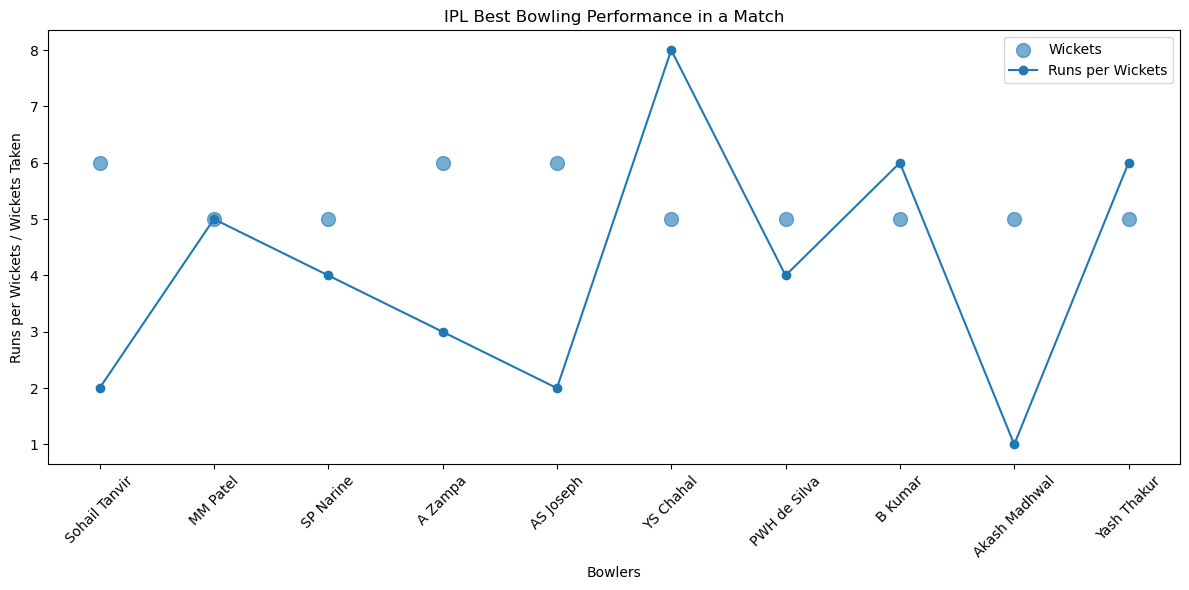

In [31]:
match_bowler_performance['Runs per Wicket']= np.round(match_bowler_performance['Runs Conceded']/match_bowler_performance['Wickets'])

# match_bowler_performance

plt.figure(figsize=(12,6))
plt.scatter(match_bowler_performance['bowler'],match_bowler_performance['Wickets'],label='Wickets',s=100,alpha=0.6)
plt.plot(match_bowler_performance['bowler'], match_bowler_performance['Runs per Wicket'],marker='o',label="Runs per Wickets")
plt.title("IPL Best Bowling Performance in a Match")
plt.xlabel("Bowlers")
plt.ylabel("Runs per Wickets / Wickets Taken")
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend()
plt.savefig("IPL_Best_Bowling_Performance.png")
plt.show()

### Top 10 Cities by Number of Matches

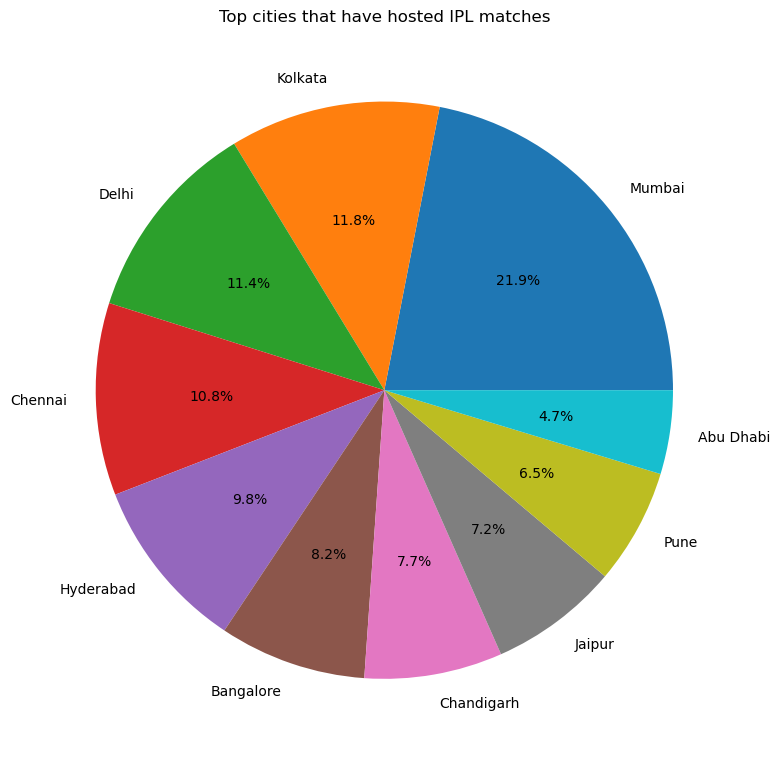

In [32]:
# ;     is used to remove text ,from outside window
top_cities= matches['city'].value_counts().reset_index(name="Match Count")[:10]

plt.figure(figsize=(8,8))
plt.pie(top_cities['Match Count'],labels=top_cities['city'],autopct="%1.1f%%");
plt.title('Top cities that have hosted IPL matches')
plt.tight_layout()
plt.savefig("Top_Cities_that_Hosted_IPL.png")
plt.show()

## Dismissal count

C:\Users\sumedh ingole\AppData\Local\Temp\ipykernel_19936\3886325360.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=deliveries, x="dismissal_kind",palette="Set2")


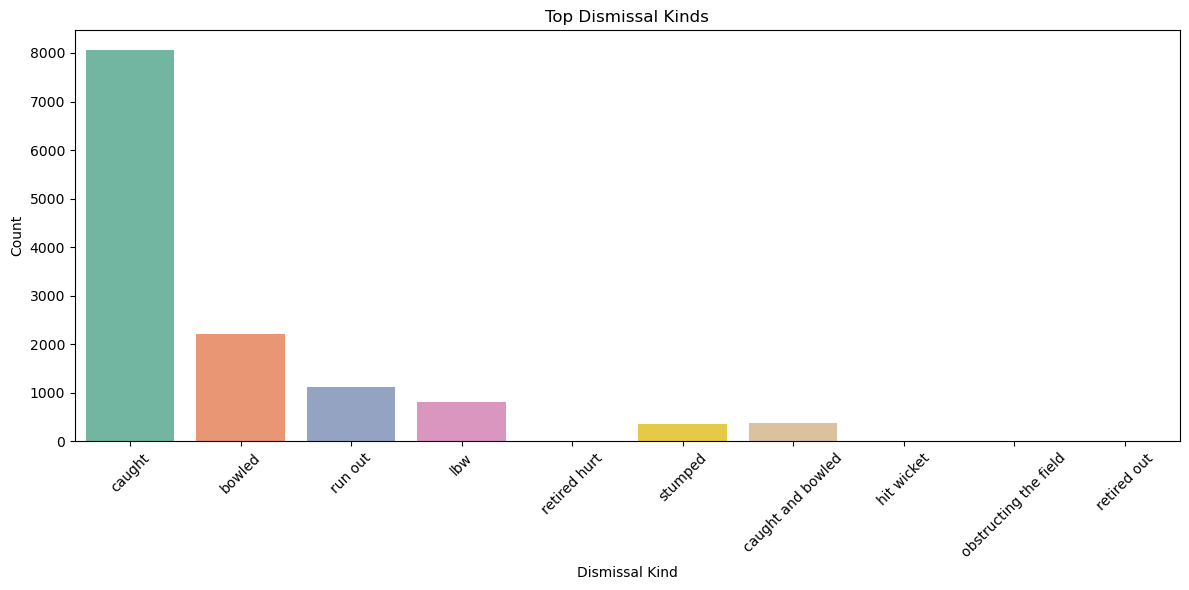

In [33]:
# deliveries
plt.figure(figsize=(12,6))
sns.countplot(data=deliveries, x="dismissal_kind",palette="Set2")
plt.title("Top Dismissal Kinds")
plt.xlabel("Dismissal Kind")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("Top_Dismissal_Kinds.png")
plt.show()

#### Top 10 Best fielder

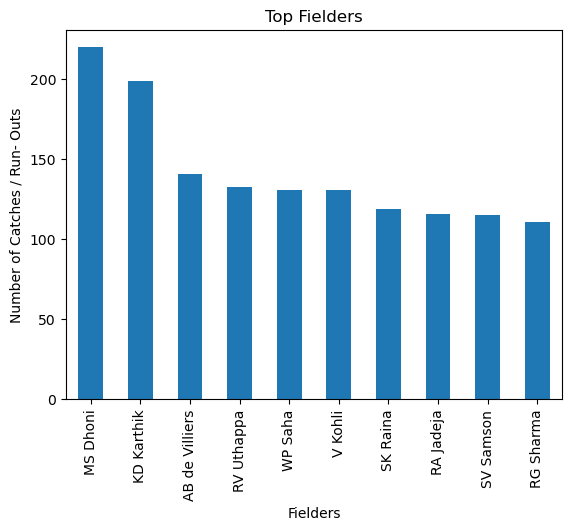

In [36]:
deliveries['fielder'].value_counts()[:10].plot(kind="bar")

plt.title("Top Fielders")
plt.xlabel("Fielders")
plt.ylabel("Number of Catches / Run- Outs")
plt.savefig("Top_fielders.png")
plt.show()

### Analysis Over by Over

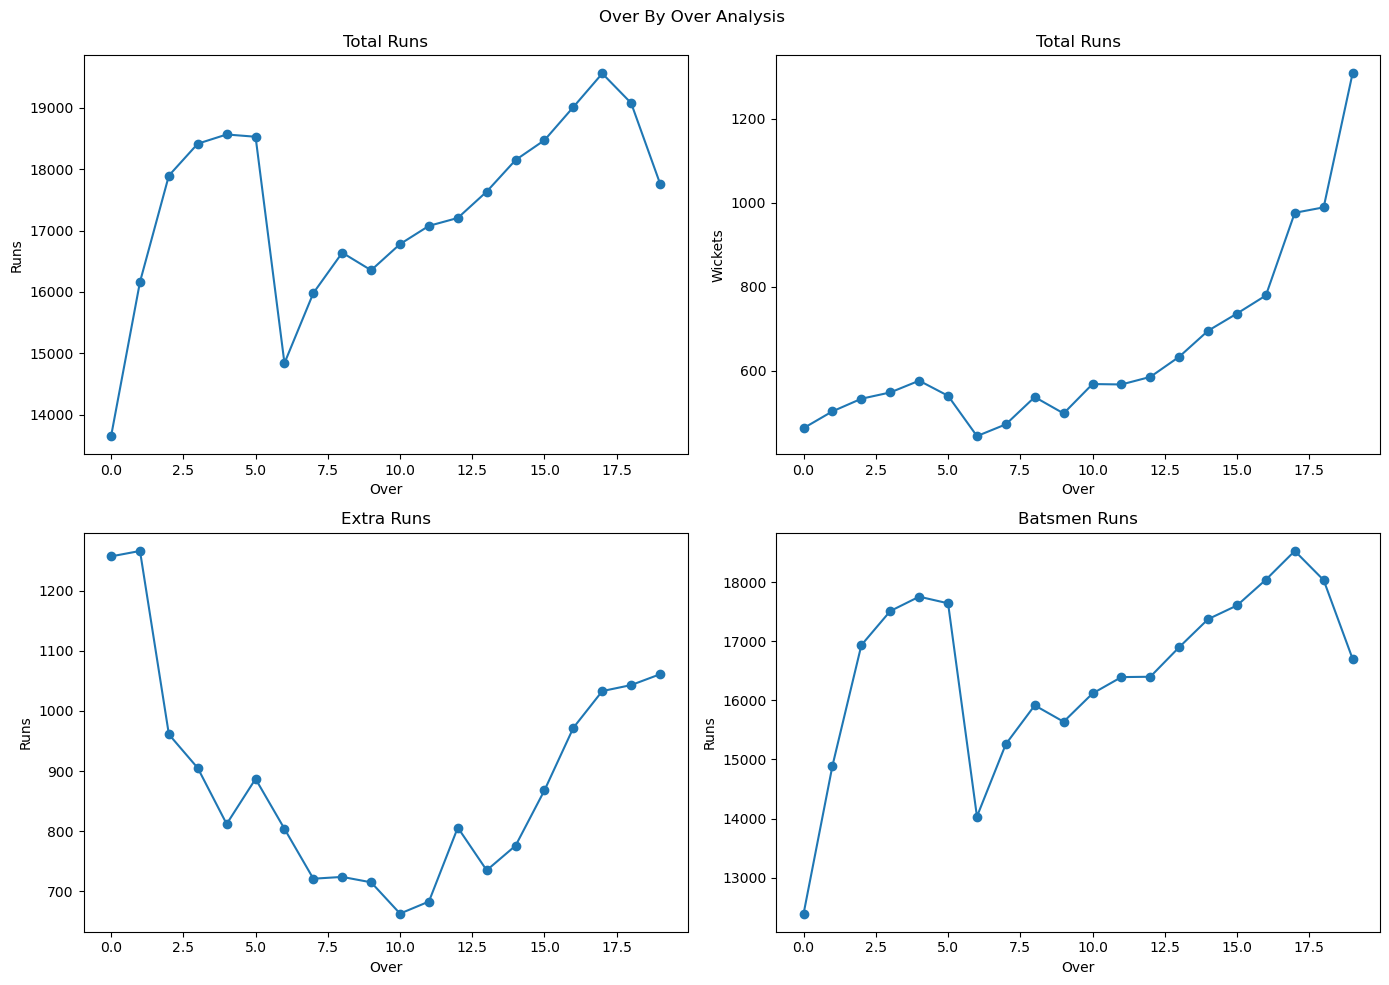

In [37]:
over_summary= deliveries.groupby('over')[['total_runs','is_wicket','extra_runs','batsman_runs']].sum()

fig, axes= plt.subplots(2,2,figsize=(14,10))
fig.suptitle("Over By Over Analysis ")

axes[0,0].plot(over_summary.index, over_summary['total_runs'],marker='o')
axes[0,0].set_title('Total Runs')
axes[0,0].set_xlabel("Over")
axes[0,0].set_ylabel("Runs")

axes[0,1].plot(over_summary.index, over_summary['is_wicket'],marker='o')
axes[0,1].set_title('Total Runs')
axes[0,1].set_xlabel("Over")
axes[0,1].set_ylabel("Wickets")

axes[1,0].plot(over_summary.index, over_summary['extra_runs'],marker='o')
axes[1,0].set_title('Extra Runs')
axes[1,0].set_xlabel("Over")
axes[1,0].set_ylabel("Runs")

axes[1,1].plot(over_summary.index, over_summary['batsman_runs'],marker='o')
axes[1,1].set_title('Batsmen Runs')
axes[1,1].set_xlabel("Over")
axes[1,1].set_ylabel("Runs")

plt.tight_layout()
plt.savefig("Over_By_Over_Analysis.png")
plt.show()

### Toss Decision

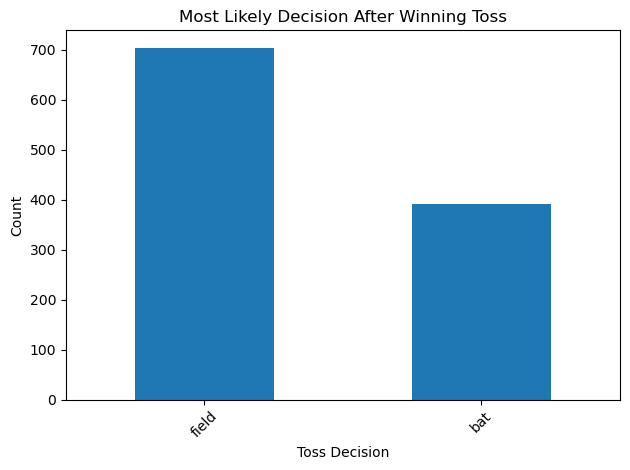

In [39]:
matches['toss_decision'].value_counts().plot(kind='bar')
plt.title("Most Likely Decision After Winning Toss")
plt.xlabel("Toss Decision")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("Most_Decision_After_Toss.png")
plt.show()